# DXY Signal Evaluation — GT-Extended 200 (Aug 2025 → Mar 2026)

Same evaluation framework as `eval_signal_v2.ipynb`, run on `results_gt_ext200_mapped.csv`.

**New in this notebook:** `true_criticality` is derived from the **trailing 7-day
rolling SD** of 15-minute DXY moves at each article's publish minute, so we can
directly measure how many articles the model tags as "high" actually *are* high
by this regime-aware standard.

Sections:
1. **Model vs Truth** — confusion matrix, precision / recall, where the model agrees and disagrees
2. **Volatility Signal** — does flagging high criticality identify larger DXY moves?
3. **Directional Accuracy** — can the model predict direction on its best-defined slices?
4. **Monthly Stability** — is performance consistent over time?
5. **Headline Numbers**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.size': 11,
})

TEAL  = '#1D9E75'
CORAL = '#D85A30'
GRAY  = '#888780'
BLUE  = '#378ADD'
AMBER = '#BA7517'

# ── Load & filter ────────────────────────────────────────────────────────
df = pd.read_csv('data/results_gt_ext200_mapped.csv')
df['dt'] = pd.to_datetime(df['article_published_utc'], utc=True, errors='coerce')

# Exclude Apr and May 2025 (same filter as eval_signal_v2)
apr_may = (df['dt'].dt.year == 2025) & (df['dt'].dt.month.isin([3, 4, 5]))
df = df[~apr_may].copy()

relevant  = df[df['is_relevant'] == True].copy()
critical  = df[df['is_critical'] == True].copy()
not_crit  = relevant[relevant['criticality_level'] == 'not high'].copy()

HORIZONS = ['pct_5m', 'pct_15m', 'pct_1h', 'pct_4h', 'pct_1d']
H_LABELS = ['5m', '15m', '1h', '4h', '1d']

def dir_accuracy(subset, horizon):
    s = subset[subset['direction'].isin(['up','down']) & subset[horizon].notna()].copy()
    if len(s) == 0:
        return np.nan, 0
    actual = s[horizon].apply(lambda x: 'up' if x > 0 else 'down')
    hits = (actual == s['direction']).sum()
    return hits / len(s), len(s)

print(f'Articles after filter          : {len(df):,}')
print(f'Relevant                       : {len(relevant):,}  ({len(relevant)/len(df)*100:.1f}%)')
print(f'Model says high (is_critical)  : {len(critical):,}  ({len(critical)/len(relevant)*100:.1f}% of relevant)')
print(f'true_criticality high          : {(df["true_criticality"]=="high").sum()}')
print(f'true_criticality not high      : {(df["true_criticality"]=="not high").sum()}')
print(f'true_criticality null          : {df["true_criticality"].isna().sum()}')
print(f'Date range                     : {df["dt"].min().date()} → {df["dt"].max().date()}')

Articles after filter          : 1,163
Relevant                       : 687  (59.1%)
Model says high (is_critical)  : 151  (22.0% of relevant)
true_criticality high          : 432
true_criticality not high      : 603
true_criticality null          : 128
Date range                     : 2025-08-01 → 2026-03-20


---
## 1 — Model Criticality vs Rolling-SD Ground Truth

Of the articles the model tags as "high", how many actually produced a 15-minute
DXY move that exceeded the trailing 7-day SD?

In [3]:
# Restrict to rows where BOTH labels are available (relevant + matched to DXY)
eligible = df[df['criticality_level'].notna() & df['true_criticality'].notna()].copy()
eligible['model_high'] = eligible['criticality_level'] == 'high'
eligible['true_high']  = eligible['true_criticality'] == 'high'

print(f"Eligible rows (model label + true label both present): {len(eligible):,}")
print(f"  model says high : {eligible['model_high'].sum()}")
print(f"  truth says high : {eligible['true_high'].sum()}")

cm = pd.crosstab(
    eligible['model_high'].map({True: 'model: high', False: 'model: not high'}),
    eligible['true_high'].map({True: 'true: high', False: 'true: not high'}),
    margins=True, margins_name='total',
)
print(f"\nConfusion matrix (n = {len(eligible):,}):")
display(cm)
print("\nAs % of total:")
display((cm / len(eligible) * 100).round(1))

Eligible rows (model label + true label both present): 619
  model says high : 137
  truth says high : 261

Confusion matrix (n = 619):


true_high,true: high,true: not high,total
model_high,,,
model: high,71,66,137
model: not high,190,292,482
total,261,358,619



As % of total:


true_high,true: high,true: not high,total
model_high,,,
model: high,11.5,10.7,22.1
model: not high,30.7,47.2,77.9
total,42.2,57.8,100.0


In [4]:
# Precision / recall / F1
TP = ( eligible['model_high'] &  eligible['true_high']).sum()
FP = ( eligible['model_high'] & ~eligible['true_high']).sum()
FN = (~eligible['model_high'] &  eligible['true_high']).sum()
TN = (~eligible['model_high'] & ~eligible['true_high']).sum()

precision = TP / (TP + FP) if (TP + FP) else float('nan')
recall    = TP / (TP + FN) if (TP + FN) else float('nan')
f1        = 2*precision*recall / (precision+recall) if (precision+recall) else float('nan')
accuracy  = (TP + TN) / len(eligible)
base_rate = (TP + FN) / len(eligible)

print('Model "high" vs rolling-SD truth:')
print(f'  base rate (true high)   : {base_rate*100:5.1f}%   ({TP+FN}/{len(eligible)})')
print(f'  precision (high → high) : {precision*100:5.1f}%   ({TP}/{TP+FP})')
print(f'  recall    (high caught) : {recall*100:5.1f}%   ({TP}/{TP+FN})')
print(f'  F1                      : {f1:.3f}')
print(f'  accuracy                : {accuracy*100:5.1f}%')
print(f'  precision lift / base   : {precision/base_rate:.2f}×')
print()
print(f'→ When the model says "high", {precision*100:.0f}% of those articles actually')
print(f'  exceeded the trailing 7-day SD (vs {base_rate*100:.0f}% base rate).')

Model "high" vs rolling-SD truth:
  base rate (true high)   :  42.2%   (261/619)
  precision (high → high) :  51.8%   (71/137)
  recall    (high caught) :  27.2%   (71/261)
  F1                      : 0.357
  accuracy                :  58.6%
  precision lift / base   : 1.23×

→ When the model says "high", 52% of those articles actually
  exceeded the trailing 7-day SD (vs 42% base rate).


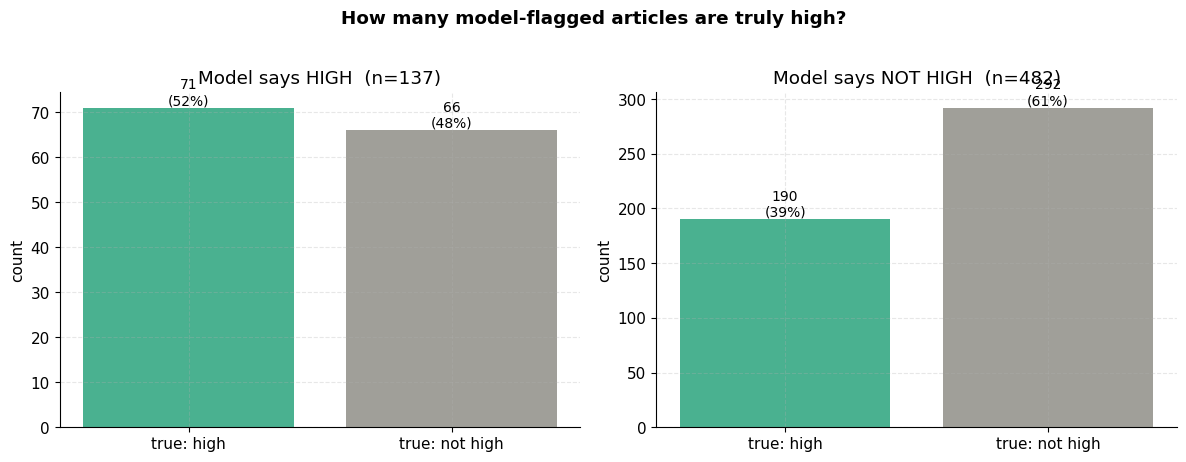

In [5]:
# Visual: composition of model-high vs model-not-high
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (mask, title) in zip(axes, [
    (eligible['model_high'],  'Model says HIGH'),
    (~eligible['model_high'], 'Model says NOT HIGH'),
]):
    grp = eligible[mask]
    n_true_h  = grp['true_high'].sum()
    n_true_nh = (~grp['true_high']).sum()
    bars = ax.bar(['true: high', 'true: not high'],
                  [n_true_h, n_true_nh],
                  color=[TEAL, GRAY], alpha=0.8)
    total = len(grp)
    ax.bar_label(bars, labels=[f'{n_true_h}\n({n_true_h/total*100:.0f}%)',
                                f'{n_true_nh}\n({n_true_nh/total*100:.0f}%)'],
                 fontsize=10)
    ax.set_title(f'{title}  (n={total})')
    ax.set_ylabel('count')

plt.suptitle('How many model-flagged articles are truly high?', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 2 — Volatility Signal

Does the model's "high" flag identify larger DXY moves? Same analysis as `eval_signal_v2` Section 1.

In [6]:
# Mean absolute moves table
rows = []
for label, grp in [('model high', critical), ('model not high', not_crit), ('all relevant', relevant)]:
    row = {'group': label, 'n': len(grp)}
    for h in HORIZONS:
        row[f'|{h}|'] = round(grp[h].abs().mean(), 5)
    rows.append(row)
mean_abs = pd.DataFrame(rows).set_index('group')
print('Mean absolute DXY % move by model criticality:')
display(mean_abs)

print('\nLift (model high / model not high):')
for h in HORIZONS:
    h_mean = critical[h].abs().mean()
    nh_mean = not_crit[h].abs().mean()
    print(f'  {h}: {h_mean/nh_mean:.2f}x')

Mean absolute DXY % move by model criticality:


,n,|pct_5m|,|pct_15m|,|pct_1h|,|pct_4h|,|pct_1d|
group,,,,,,
model high,151,0.03875,0.06287,0.09794,0.1634,0.29275
model not high,536,0.01594,0.02919,0.05864,0.1198,0.27027
all relevant,687,0.02104,0.03664,0.06745,0.1298,0.27509



Lift (model high / model not high):
  pct_5m: 2.43x
  pct_15m: 2.15x
  pct_1h: 1.67x
  pct_4h: 1.36x
  pct_1d: 1.08x


In [7]:
# Mann-Whitney U
print('Mann-Whitney U — one-sided (H1: model-high produces larger |moves|):\n')
mw_rows = []
for h, hl in zip(HORIZONS, H_LABELS):
    hv  = critical[h].dropna().abs()
    nhv = not_crit[h].dropna().abs()
    if len(hv) == 0 or len(nhv) == 0:
        continue
    stat, p = mannwhitneyu(hv, nhv, alternative='greater')
    mw_rows.append({
        'horizon': hl,
        'n high': len(hv), 'n not-high': len(nhv),
        'mean |high|': f'{hv.mean():.4f}%', 'mean |not-high|': f'{nhv.mean():.4f}%',
        'lift': f'{hv.mean()/nhv.mean():.2f}x',
        'p-value': f'{p:.4f}',
        'sig (p<0.05)': 'Y' if p < 0.05 else 'N',
    })
display(pd.DataFrame(mw_rows).set_index('horizon'))

Mann-Whitney U — one-sided (H1: model-high produces larger |moves|):



,n high,n not-high,mean |high|,mean |not-high|,lift,p-value,sig (p<0.05)
horizon,,,,,,,
5m,139,483,0.0387%,0.0159%,2.43x,0.0000,Y
15m,137,482,0.0629%,0.0292%,2.15x,0.0000,Y
1h,137,474,0.0979%,0.0586%,1.67x,0.0001,Y
4h,130,437,0.1634%,0.1198%,1.36x,0.0012,Y
1d,106,388,0.2927%,0.2703%,1.08x,0.2230,N


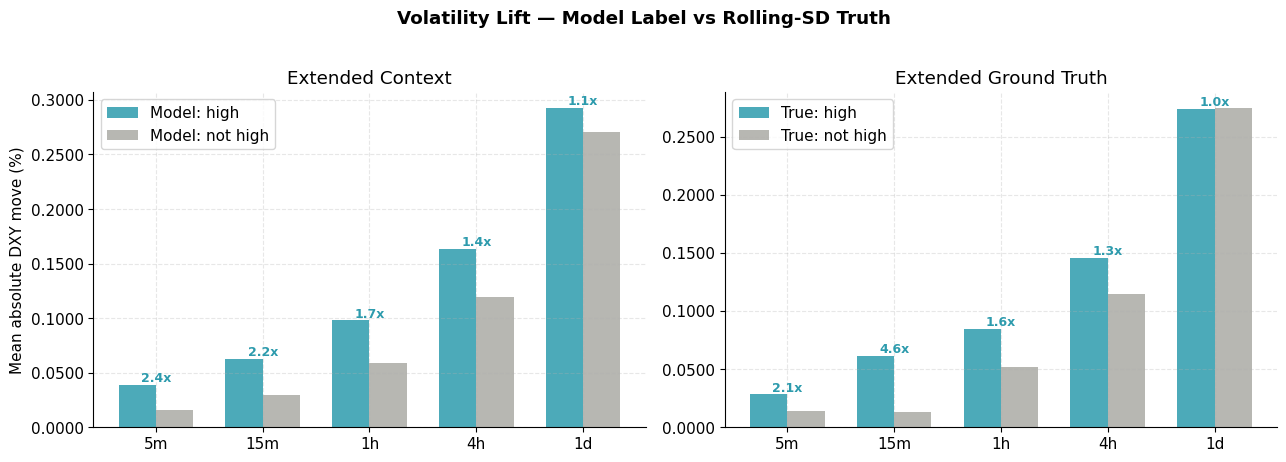

In [8]:
TEAL = '#2D9BAD'
# Chart: mean |move| — model label (left) vs rolling-SD truth (right)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(HORIZONS))
w = 0.35

# Left: model label
ax = axes[0]
h_means  = [critical[h].abs().mean() for h in HORIZONS]
nh_means = [not_crit[h].abs().mean() for h in HORIZONS]
ax.bar(x - w/2, h_means,  w, label='Model: high', color=TEAL, alpha=0.85)
ax.bar(x + w/2, nh_means, w, label='Model: not high', color=GRAY, alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(H_LABELS)
ax.set_ylabel('Mean absolute DXY move (%)')
ax.set_title('Extended Context')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.4f}'))
for i, (hm, nhm) in enumerate(zip(h_means, nh_means)):
    if nhm > 0:
        ax.text(i, hm + 0.00005, f'{hm/nhm:.1f}x', ha='center', va='bottom',
                fontsize=9, color=TEAL, fontweight='bold')

# Right: rolling-SD truth
true_high = df[df['true_criticality'] == 'high']
true_nh   = df[df['true_criticality'] == 'not high']
ax2 = axes[1]
th_means  = [true_high[h].abs().mean() for h in HORIZONS]
tnh_means = [true_nh[h].abs().mean()   for h in HORIZONS]
ax2.bar(x - w/2, th_means,  w, label='True: high', color=TEAL, alpha=0.85)
ax2.bar(x + w/2, tnh_means, w, label='True: not high', color=GRAY, alpha=0.6)
ax2.set_xticks(x); ax2.set_xticklabels(H_LABELS)
ax2.set_title('Extended Ground Truth')
ax2.legend()
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.4f}'))
for i, (hm, nhm) in enumerate(zip(th_means, tnh_means)):
    if nhm > 0:
        ax2.text(i, hm + 0.00005, f'{hm/nhm:.1f}x', ha='center', va='bottom',
                 fontsize=9, color=TEAL, fontweight='bold')

plt.suptitle('Volatility Lift — Model Label vs Rolling-SD Truth', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3 — Directional Accuracy

Model-predicted direction vs actual DXY move direction. Same slicing as `eval_signal_v2`.

In [9]:
# Directional accuracy table by slice
slices = {
    'All Critical':                critical,
    'Event Tier 1 (Fed/Macro)':    critical[critical['event_tier'] == 1.0],
    'NFP / Jobs (Events 10 & 11)': critical[critical['event_number'].isin([10, 11])],
    'Table used':                  critical[critical['table_used'] == True],
    'Non-Critical (Baseline)':     not_crit,
}

rows = []
for name, grp in slices.items():
    row = {'slice': name, 'n': len(grp)}
    for h, hl in zip(HORIZONS, H_LABELS):
        acc, n = dir_accuracy(grp, h)
        row[hl] = f'{acc*100:.1f}% ({n})' if n > 0 else 'n/a'
    rows.append(row)

acc_table = pd.DataFrame(rows).set_index('slice')
print('Directional accuracy by slice:')
display(acc_table)

Directional accuracy by slice:


,n,5m,15m,1h,4h,1d
slice,,,,,,
All Critical,151,51.1% (137),49.6% (135),48.1% (135),48.4% (128),45.2% (104)
Event Tier 1 (Fed/Macro),79,47.9% (73),52.8% (72),47.2% (72),46.4% (69),44.9% (49)
NFP / Jobs (Events 10 & 11),33,59.4% (32),67.7% (31),51.6% (31),48.4% (31),52.9% (17)
Table used,51,53.1% (49),60.4% (48),54.2% (48),52.1% (48),48.3% (29)
Non-Critical (Baseline),536,52.7% (182),48.9% (182),48.9% (178),51.2% (168),50.0% (140)


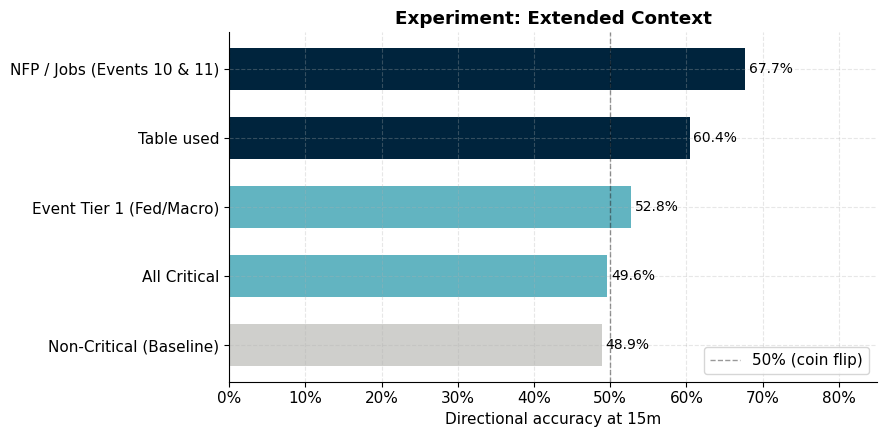

In [17]:
# Chart: directional accuracy at 15m by slice (horizontal bar, sorted)
slice_names = list(slices.keys())
acc_15m = []
ns_15m  = []
for name, grp in slices.items():
    acc, n = dir_accuracy(grp, 'pct_15m')
    acc_15m.append(acc if not np.isnan(acc) else 0)
    ns_15m.append(n)

colors = [TEAL, TEAL, '#00243D', '#00243D', GRAY]
alphas = [0.75, 0.75, 1, 1, 0.4]

sorted_idx = np.argsort(acc_15m)
slice_names_s = [slice_names[i] for i in sorted_idx]
acc_15m_s     = [acc_15m[i]     for i in sorted_idx]
ns_15m_s      = [ns_15m[i]      for i in sorted_idx]
colors_s      = [colors[i]      for i in sorted_idx]
alphas_s      = [alphas[i]      for i in sorted_idx]

fig, ax = plt.subplots(figsize=(9, 4.5))
y_pos = np.arange(len(slice_names_s))
for i, (val, col, alp) in enumerate(zip([a*100 for a in acc_15m_s], colors_s, alphas_s)):
    ax.barh(i, val, color=col, alpha=alp, height=0.6)

ax.axvline(50, color='black', linewidth=1, linestyle='--', alpha=0.4, label='50% (coin flip)')
for i, (acc, n) in enumerate(zip(acc_15m_s, ns_15m_s)):
    ax.text(acc*100 + 0.5, i, f'{acc*100:.1f}%', va='center', fontsize=10)

ax.set_yticks(y_pos); ax.set_yticklabels(slice_names_s)
ax.set_xlabel('Directional accuracy at 15m')
ax.set_xlim(0, 85)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Experiment: Extended Context', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

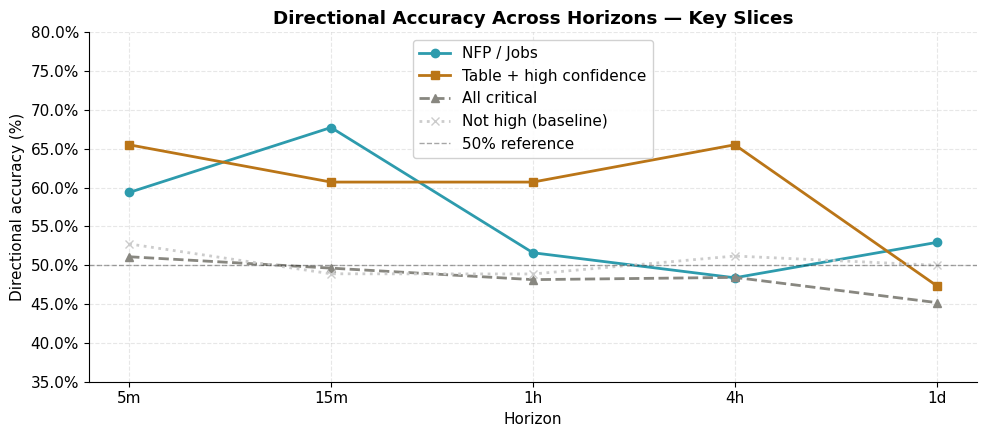

In [11]:
# Direction accuracy across horizons for key slices
key_slices = {
    'NFP / Jobs':              critical[critical['event_number'].isin([10, 11])],
    'Table + high confidence': critical[(critical['table_used'] == True) &
                                        (critical['direction_confidence'] == 'high')],
    'All critical':            critical,
    'Not high (baseline)':     not_crit,
}

fig, ax = plt.subplots(figsize=(10, 4.5))
slice_colors = [TEAL, AMBER, GRAY, '#cccccc']
slice_styles = ['-o', '-s', '--^', ':x']

for (name, grp), color, style in zip(key_slices.items(), slice_colors, slice_styles):
    accs = []
    for h in HORIZONS:
        acc, n = dir_accuracy(grp, h)
        accs.append(acc * 100 if not np.isnan(acc) else np.nan)
    ax.plot(H_LABELS, accs, style, color=color, label=name, linewidth=2, markersize=6)

ax.axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.35, label='50% reference')
ax.set_ylabel('Directional accuracy (%)'); ax.set_xlabel('Horizon')
ax.set_ylim(35, 80)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(framealpha=0.9)
ax.set_title('Directional Accuracy Across Horizons — Key Slices', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4 — Monthly Stability

Includes true-high precision per month: of the articles the model flagged as high
in each month, what fraction were actually high by the rolling-SD standard?

In [12]:
critical['ym'] = critical['dt'].dt.to_period('M')

monthly_rows = []
for ym, grp in critical.groupby('ym'):
    acc15, n15 = dir_accuracy(grp, 'pct_15m')
    acc1h, n1h = dir_accuracy(grp, 'pct_1h')
    # Precision against rolling-SD truth for this month
    grp_elig = grp[grp['true_criticality'].notna()]
    true_h = (grp_elig['true_criticality'] == 'high').sum()
    prec = true_h / len(grp_elig) if len(grp_elig) else np.nan
    monthly_rows.append({
        'month':          str(ym),
        'n critical':     len(grp),
        '15m acc':        round(acc15 * 100, 1) if not np.isnan(acc15) else np.nan,
        '1h acc':         round(acc1h * 100, 1) if not np.isnan(acc1h) else np.nan,
        'mean |15m|':     round(grp['pct_15m'].abs().mean() * 100, 4),
        'true_high prec': round(prec * 100, 1) if not np.isnan(prec) else np.nan,
    })

monthly_df = pd.DataFrame(monthly_rows)
print('Monthly breakdown (model-high articles):')
display(monthly_df.set_index('month'))

Monthly breakdown (model-high articles):


,n critical,15m acc,1h acc,mean |15m|,true_high prec
month,,,,,
2025-08,35,50.0,50.0,11.1263,43.3
2025-09,21,61.9,42.9,6.6891,57.1
2025-10,18,31.2,56.2,6.1274,56.2
2025-11,9,44.4,33.3,2.8867,66.7
2025-12,9,37.5,37.5,6.9949,62.5
2026-01,22,47.1,5.9,4.6470,55.6
2026-02,22,57.9,73.7,3.1861,45.0
2026-03,15,53.3,73.3,3.9791,46.7


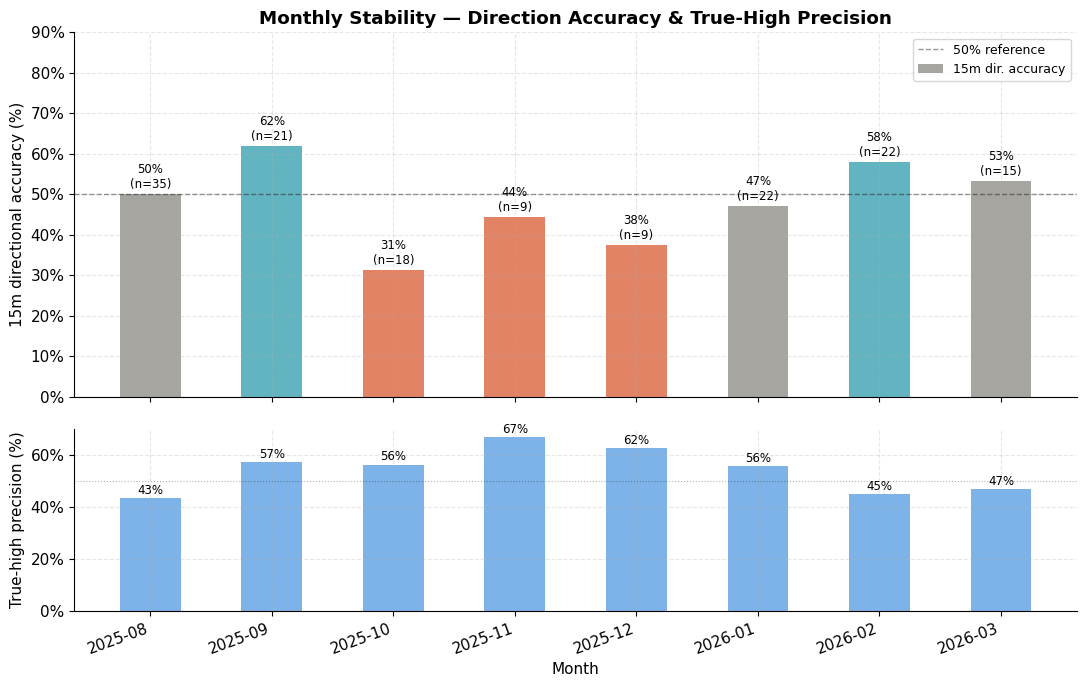

In [13]:
# Chart: monthly direction accuracy + true-high precision
months    = monthly_df['month'].tolist()
acc_vals  = monthly_df['15m acc'].tolist()
n_vals    = monthly_df['n critical'].tolist()
prec_vals = monthly_df['true_high prec'].tolist()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

bar_colors = [TEAL if a >= 55 else CORAL if a < 45 else GRAY for a in acc_vals]
ax1.bar(months, acc_vals, color=bar_colors, alpha=0.75, width=0.5, label='15m dir. accuracy')
ax1.axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.4, label='50% reference')
for i, (a, n) in enumerate(zip(acc_vals, n_vals)):
    if not np.isnan(a):
        ax1.text(i, a + 0.8, f'{a:.0f}%\n(n={n})', ha='center', va='bottom', fontsize=8.5)
ax1.set_ylabel('15m directional accuracy (%)')
ax1.set_ylim(0, 90)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.legend(loc='upper right', fontsize=9)
ax1.set_title('Monthly Stability — Direction Accuracy & True-High Precision', fontweight='bold')

ax2.bar(months, prec_vals, color=BLUE, alpha=0.65, width=0.5)
for i, p in enumerate(prec_vals):
    if not np.isnan(p):
        ax2.text(i, p + 0.5, f'{p:.0f}%', ha='center', va='bottom', fontsize=8.5)
ax2.set_ylabel('True-high precision (%)')
ax2.set_xlabel('Month')
ax2.axhline(50, color='black', linewidth=0.8, linestyle=':', alpha=0.3)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## 5 — Headline Numbers

In [14]:
vol_lift_15m = critical['pct_15m'].abs().mean() / not_crit['pct_15m'].abs().mean()
_, p_15m = mannwhitneyu(critical['pct_15m'].dropna().abs(),
                         not_crit['pct_15m'].dropna().abs(), alternative='greater')
nfp_acc, nfp_n = dir_accuracy(critical[critical['event_number'].isin([10,11])], 'pct_15m')
overall_acc, overall_n = dir_accuracy(critical, 'pct_15m')

print('=' * 62)
print('  HEADLINE NUMBERS — GT-Extended 200')
print('=' * 62)
print(f'  Articles                     : {len(df):,}')
print(f'  Relevant                     : {len(relevant):,}')
print(f'  Model says high              : {len(critical):,}  ({len(critical)/len(relevant)*100:.1f}% of relevant)')
print()
print('  VOLATILITY SIGNAL (model label)')
print(f'  High criticality lift        : {vol_lift_15m:.2f}x at 15m')
print(f'  Mann-Whitney p               : {p_15m:.4f}  (sig: {"yes" if p_15m < 0.05 else "no"})')
print()
print('  DIRECTIONAL ACCURACY AT 15m')
print(f'  All critical                 : {overall_acc*100:.1f}%  (n={overall_n})')
if not np.isnan(nfp_acc):
    print(f'  NFP / Jobs                   : {nfp_acc*100:.1f}%  (n={nfp_n})')
print()
print('  MODEL vs ROLLING-SD TRUTH')
print(f'  Eligible (both labels)       : {len(eligible):,}')
print(f'  Precision (high -> true high): {precision*100:.1f}%  ({TP}/{TP+FP})')
print(f'  Recall (true high caught)    : {recall*100:.1f}%  ({TP}/{TP+FN})')
print(f'  F1                           : {f1:.3f}')
print(f'  Base rate (true high)        : {base_rate*100:.1f}%')
print(f'  Precision lift / base        : {precision/base_rate:.2f}x')
print()
best_month = monthly_df.loc[monthly_df['15m acc'].idxmax()]
print(f'  BEST MONTH')
print(f'  {best_month["month"]}   : {best_month["15m acc"]}% dir accuracy  (n={best_month["n critical"]})')
print('=' * 62)

  HEADLINE NUMBERS — GT-Extended 200
  Articles                     : 1,163
  Relevant                     : 687
  Model says high              : 151  (22.0% of relevant)

  VOLATILITY SIGNAL (model label)
  High criticality lift        : 2.15x at 15m
  Mann-Whitney p               : 0.0000  (sig: yes)

  DIRECTIONAL ACCURACY AT 15m
  All critical                 : 49.6%  (n=135)
  NFP / Jobs                   : 67.7%  (n=31)

  MODEL vs ROLLING-SD TRUTH
  Eligible (both labels)       : 619
  Precision (high -> true high): 51.8%  (71/137)
  Recall (true high caught)    : 27.2%  (71/261)
  F1                           : 0.357
  Base rate (true high)        : 42.2%
  Precision lift / base        : 1.23x

  BEST MONTH
  2025-09   : 61.9% dir accuracy  (n=21)
